<a href="https://colab.research.google.com/github/palarunava/machine-learning-courses/blob/main/machine-learning-specialization/supervised-ml-regression-classification/C3_Unsupervised_Learning_Recommender_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <u>Anomaly Detection</u>

* Uses Density Estimation

## Gaussian (Normal) Distribution
$$
p(x) = \frac{1}{\sqrt{2\pi}{\sigma}}e^\frac{-(x-\mu)^2}{2\sigma^2}
$$

<div style="display: flex;">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/7/74/Normal_Distribution_PDF.svg/960px-Normal_Distribution_PDF.svg.png" width="450"/>
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/8/8c/Standard_deviation_diagram.svg/960px-Standard_deviation_diagram.svg.png" width="450"/>
</div>

## Density Estimation
Training Set: $\{x^{(1)}, x^{(2)}, ..., x^{(m)}\}$  
Each example $x^{(i)}$ has n features.

$p(x) = p(x_1;\mu_1, \sigma_1^2) * p(x_2;\mu_2, \sigma_2^2) \; * \; .... \; * \; p(x_n;\mu_n, \sigma_n^2)$

$p(x) = \displaystyle\prod_{j=1}^{n} p(x_j;\mu_j, \sigma_j^2)$

## Anomaly Detection Algorithm
1. Choose n features, that you think might be indicative of anomalous examples.
2. Fit parameters, $\mu_1, \; ..., \; \mu_n, \sigma_1^2, \; ...., \; \sigma_n^2$
$$
\mu_j = \frac{1}{m} \sum_{j=1}^{m} x_j^{(i)} \\
\sigma_j^2 = \frac{1}{m} \sum_{i=1}^{m}(x_j^{(i)} - \mu_j^{(i)})^2
$$
3. Given new example x, compute p(x):
$$
p(x) = \prod_{j=1}^{n}p(x_j;\mu_j, \sigma_j^2) \\
p(x_j;\mu_j, \sigma_j^2) = \prod_{j=1}^{n} \frac{1}{\sqrt{2\pi}{\sigma_j}}e^\frac{-(x_j-\mu_j)^2}{2{\sigma_j}^{2}}
$$
4. Anomaly if p(x) < $\epsilon$, where $\epsilon$ is the threshold.

## Tips and Tricks
1. Anomaly detection assumes that we understand what normal or expected behavior looks like in a favorable environment. The goal is to identify samples that significantly deviate from this normal pattern. Because the model learns the characteristics of normal data, it can detect unusual instances as anomalies. This is why anomaly detection methods can often be trained using only positive (normal) samples.
2. Anomaly detection assumes that the data follows a normal (Gaussian) distribution, so it is recommended to choose features that are Gaussian.
3. Ways to convert a non-Gaussian feature into a Gaussian feature:
>* $x \rightarrow log(x+c)$
>* $x \rightarrow x^\frac{1}{2} or \sqrt{x}$
>* $x \rightarrow x^\frac{1}{3} or \sqrt[3]{x}$

## Examples
* Finding new previously unseen defect in manufacturing
* Monitoring machines in a Data Center
* Fraud detection

# <u>Recommender Systems</u>

## Cost Function
### To learn parameters $w^{(j)}$, $b^{(j)}$ for user j
$$
\min_{w^{(j)}, b^{(j)}}J(w^{(j)}, b^{(j)}) = \frac{1}{2m^{(j)}}\sum_{i: r(i, j)=1}(w^{(j)}. x^{(j)} + b^{(j)} - y^{(i, j)})^2 + \frac{\lambda}{2m^{(j)}}\sum_{k=1}^{n}(w_k^{(j)})^2
$$

where  
r(i, j) = 1 if user j has rated movie i (0 otherwise)  
$y^{(i, j)}$ = rating given by user j on movie i (if defined)  
$w^{(j)}, b^{(j)}$ = parameters for user j  
$x^{(i)}$ = feature vector for movie j
$m^{(j)}$ = number of movies rated by user j
<br><br><br>
### To learn parameters $w^{(1)}$, $b^{(1)}$, $w^{(2)}$, $b^{(2)}$, ..., $w^{(n_u)}$, $b^{(n_u)}$ for all users where $n_u$ is the number of users
$$
J
\begin{pmatrix}
w^{(1)} & \cdots & w^{(n_u)} \\
b^{(1)} & \cdots & b^{(n_u)}
\end{pmatrix} = \frac{1}{2}\sum_{j=1}^{n_u}\sum_{i: r(i, j)=1}(w^{(j)}. x^{(j)} + b^{(j)} - y^{(i, j)})^2 + \frac{\lambda}{2}\sum_{j=1}^{n_u}\sum_{k=1}^{n}(w_k^{(j)})^2
$$
Dividing the cost function by $m^{(j)}$ makes very little difference, hence, removed.

This looks very much like the linear regression cost function. The only difference is that we are learning a different linear regression model for each user at the same time.

## Collaborative Filtering
>Recommend items to you based on ratings of users who gave similar ratings as you.  
>Given enough number of labeled samples it is possible to learn the features of the sample being evaluated.

### Modifed Cost Function
$$
\min_{\substack{
w^{(1)}, ..., w^{(n_u)} \\
b^{(1)}, ..., b^{(n_u)} \\
x^{(1)}, ..., x^{(n_m)}
}}J(w, b, x) = \frac{1}{2}
\sum_{(i, j): r(i, j)=1}
(w^{(j)}.x^{(i)} + b^{(j)} - y^{(i, j)})^2 +
\frac{\lambda}{2}\sum_{j=1}^{n_u}\sum_{k=1}^{n}(w_k^{(j)})^2 +
\frac{\lambda}{2}\sum_{1=1}^{n_m}\sum_{k=1}^{n}(x_k^{(i)})^2
$$

### Gradient Descent
$\text{repeat \{}$  
$\qquad w_i^{(j)} = w_i^{(j)} - \alpha\frac{\partial}{\partial w_i^{(j)}} J(w, b, x)$  
$\qquad b^{(j)} = b^{(j)} - \alpha\frac{\partial}{\partial b^{(j)}} J(w, b, x)$  
$\qquad x_k^{(i)} = x_k^{(i)} - \alpha\frac{\partial}{\partial x_k^{(i)}} J(w, b, x)$  
$\text{\}}$

### Binary labels
#### Modifed Cost Function
$$
J(w, b, x) =
\sum_{(i, j): r(i, j)=1}
L(f_{(w, b, x)}, y^{(i, j)})
$$<br>
$\text{where } L(f_{(w, b, x)}, y^{(i, j)}) = -y^{(i, j)}log\big(f_{(w, b, x)}(x)\big) - (1-y^{(i, j)})log\big(1-f_{(w, b, x)}(x)\big)$<br><br>
$f_{(w, b, x)}(x) = g(w^{(j)}.x^{(i)} + b^{(j)})$

### Finding related items
To find other items related to an item, find item k with $x^{(k)}$ similar to $x^{(i)}$  
i.e. with the least distance,
$\displaystyle\sum_{l=1}^{n}(x_l^{(k)} - x_l^{(i)})^2$ or $\begin{Vmatrix} x^{(k)} - x^{(i)} \end{Vmatrix}^2$

### Tips and Tricks
* Use Mean Normalization. Speeds up the algorithm and helps the algorithm learn better and helps the model make reasonable predictions.

### Limitations
* Cold Start Problem - Doesn't do too well with newly publised data that is still unlabeled.

## Content-based Filtering
>Recommend items to you based on features of user and item to find good match  
>It combines two different neural networks to train on the movie features and the user features and learn a n-dimensional vector with same number of output features. It then calculates the dot product of these two similar-sized vectors produced by both the neural networks and arrives at final output.

### Modified Cost Function
$$
J = \sum_{(i, j): r(i, j)=1}
\big(
v_u^{(j)}.v_m^{(i)} - y^{(i, j)}
\big)^2
\text{ + NN regularization term}
$$


In [ ]:
#@title Auto Diff with TensorFlow
import tensorflow as tf

w = tf.Variable(3.0)
x = 1.0
y = 1.0 # Target value
alpha = 0.01

iterations = 30
for iter in range(iterations):
    # Use TensorFlow's Gradient Tape to record the steps used to compute the cost J, to enable auto differentiation
    with tf.GradientTape() as tape:
        fwb = w*x
        costJ = (fwb - y)**2

    # Use the Gradient Tape to calculate the gradients of the cost with respect to the parameter w
    [dJdw] = tape.gradient(costJ, [w])

    # Run one step of gradient descent by updating the value of w to reduce the cost
    w.assign_add(-alpha * dJdw)

print(f'w: {w.numpy()}')

w: 2.090968370437622


In [ ]:
#@title Pseudo-code for implementing collaborative filtering with TensorFlow [DO NOT EXECUTE]
from ast import Num
# Instantiate an optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-1)

iterations = 200
for iter in range(iterations):
    # Use TensorFlow's Gradient Tape to record the steps used to compute the cost J, to enable auto differentiation
    with tf.GradientTape() as tape:
        # Compute the cost (forward pass is included in cost)
        cost_value = cofiCostFuncV(
            X, # movie features
            W, # Weights
            b, # Bias
            Ynorm, # Outputs normalized
            R, # Movies that have been rated
            num_users, # number of users
            num_movies, # number of movies
            _lambda # Regularization parameter
        )

    # Use the gradient tape to automatically retrieve the gradients of the trainable variables with respect to the loss
    grads = tape.gradient(
        cost_value,
        [X, W, b]
    )

    # Run one step of gradient descent by updating the value of the variables to minimize the loss
    optimizer.apply_gradients(zip(grads, [X, W, b]))

In [ ]:
#@title Pseudo-code for implementing content-based filtering with TensorFlow
import tensorflow as tf

user_NN = tf.keras.models.Sequential([
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(32)
])

item_NN = tf.keras.models.Sequential([
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(32)
])

# Create the user input and point to the base network
input_user = tf.keras.layers.Input(shape=(num_user_features))
vu = user_NN(input_user)
vu = tf.linalg.l2_normalize(vu, axis=1)

# Create the item input and point to the base network
input_item = tf.keras.layers.Input(shape=(num_item_features))
vm = item_NN(input_item)
vm = tf.linalg.l2_normalize(vm, axis=1)

# Measure the similarity of the two vector outputs
output = tf.keras.layers.Dot(axes=1)([vu, vm])

# Specify the inputs and output of the model
model = Model([input_user, input_item], output)

# Specify the cost function
cost_fn = tf.keras.losses.MeanSquaredError()

# Principal Component Analysis (PCA)
> Used mainly for visualizing higher-dimensional data.
## Prerequisite
* The data should be normalized to have zero mean.

## Objective
> To select an axis for the data that maximizes the variance

## Finding a unit vector in any given direction

To find the unit vector in the direction of $\vec{v} = 3\hat{i} + 4\hat{j}$

## Tips and Tricks
* The predicted axes are always 90$^\circ$ to each other.

## Limitation
* Reconstruction of the original data is just an approximation an not always correct.

Magnitude: $||\vec{v}|| = \sqrt{3^2 + 4^2} = 5$  
Unit Vector: $\vec{u} = \frac{3\hat{i} + 4\hat{j}}{5} = \begin{bmatrix}
0.6 \\
0.8
\end{bmatrix}
$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd
import seaborn as sns

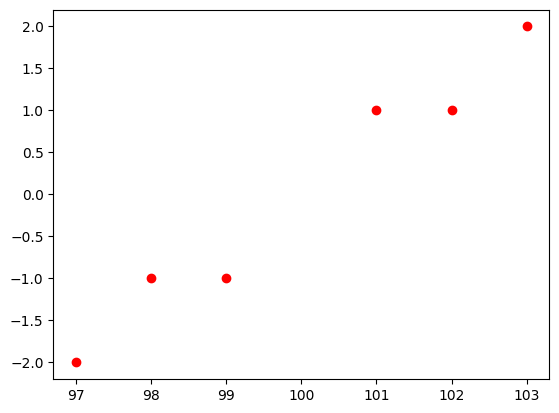

In [ ]:
X = np.array([[ 99,  -1],
       [ 98,  -1],
       [ 97,  -2],
       [101,   1],
       [102,   1],
       [103,   2]])
plt.plot(X[:,0], X[:,1], 'ro')

In [ ]:
pca_1 = PCA(n_components=1)
pca_1.fit(X)
print(f'Variance Ratio: {pca_1.explained_variance_ratio_}')
X_trans_1 = pca_1.transform(X)
print(f'Reconstructed X: {X_trans_1}')

Variance Ratio: [0.99244289]
Reconstructed X: [[-1.38340578]
 [-2.22189802]
 [-3.6053038 ]
 [ 1.38340578]
 [ 2.22189802]
 [ 3.6053038 ]]


### Visualize a multi-dimensional dataset using PCA to find patterns

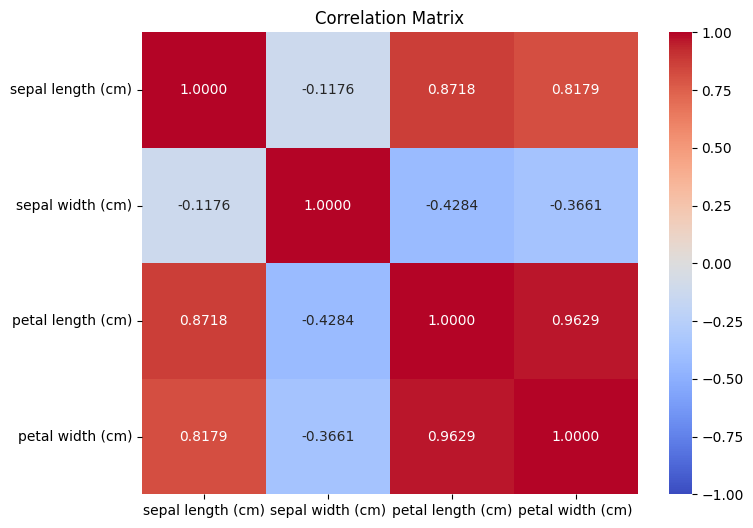

In [ ]:
from sklearn.datasets import load_iris
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)

corr = df.corr()

# Basic Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr,
    annot=True,          # Adds correlation values to cells
    cmap="coolwarm",     # Color palette
    fmt=".4f",           # Decimal precision
    vmin=-1,             # Scale range
    vmax=1
)
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# Loading the PCA object
pca = PCA(n_components = 2) # Here we choose the number of components that we will keep.
X_pca = pca.fit_transform(df)
df_pca = pd.DataFrame(X_pca, columns = ['principal_component_1','principal_component_2'])
df_pca.head()

,principal_component_1,principal_component_2
0,-2.684126,0.319397
1,-2.714142,-0.177001
2,-2.888991,-0.144949
3,-2.745343,-0.318299
4,-2.728717,0.326755


Text(0.5, 1.0, 'PCA decomposition')

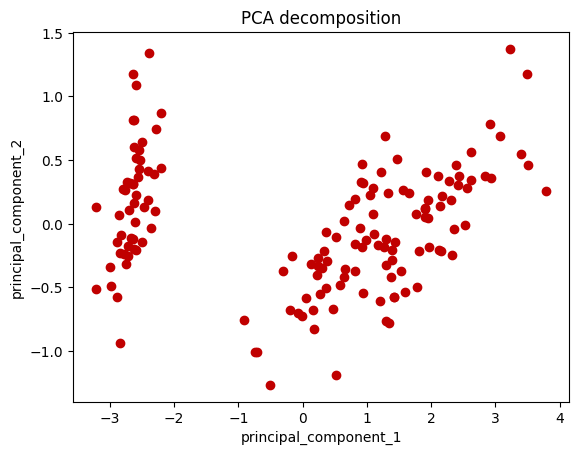

In [ ]:
plt.scatter(df_pca['principal_component_1'],df_pca['principal_component_2'], color = "#C00000")
plt.xlabel('principal_component_1')
plt.ylabel('principal_component_2')
plt.title('PCA decomposition')

In [ ]:
# pca.explained_variance_ration_ returns a list where it shows the amount of variance explained by each principal component.
sum(pca.explained_variance_ratio_)

np.float64(0.9776852063187977)

# <u>Reinforcement Learning</u>

## Objective
Find a policy $\pi$ that tells you what action (a=$\pi$(s)) to take in every state (s) so as to maximize the return. This is based on the Markov Decision Process, which states that future state of any environment depends only on the current state and not on any previous states.
<br><br>
A <b><i>policy</i></b> is a function $\pi$(s) = a mapping from states to actions, that tells you what action a to take in a given state s.
<br><br>
<b><i>Return</i></b> = $R_1 + \gamma R_2 + \gamma^2 R_3$ + .... (until terminal state)  
$R_1$ = reward associate with state $S_1$

## Algorithm

### State-action value function
$Q(s, a) = \text{"Return" if you  }$  
* $\text{start in state s}$
* $\text{take action a once}$
* $\text{then behave optimally after that}$

The best possible return from state s is $\displaystyle\max_aQ(s, a)$.  
The best possible action in state s is the action a that gives $\displaystyle\max_aQ(s, a)$.

### Bellman Equation
$
Q(s, a) = R(s) + \gamma \displaystyle\max_{a^\prime}Q(s^\prime, a^\prime) \\
\text{where} \\
\text{s: current state} \\
\text{a: current action} \\
\text{s}^\prime\text{: state you get to after taking action a} \\
\text{a}^\prime\text{: action that you take in state s}^\prime
$

### Pseudo-code
$
\text{Initialize neural network randomly as guess of Q(s, a)} \\
\text{Repeat \{} \\
\quad \text{Take actions in the lunar lander. Get (s, a, R(s), s}^\prime\text{).} \\
\quad \text{Store 10000 most recent (s, a, R(s), s}^\prime\text{) tuples.} \\
\quad \text{Train neural network:} \\
\quad\quad \text{Create training set of 10000 examples using} \\
\quad\quad\quad x = (s, a) \quad and \quad y = R(s) + \gamma \displaystyle\max_{a^{\prime}}Q(s^\prime, a^\prime) \\
\quad\quad \text{Train } Q_{new} \text{ such that } Q_{new}(s, a) \approx y. \\
\quad \text{Set } Q = Q_{new} \\
\text{\}}
$

The neural network architecture is also called DQN.

## Tips and Tricks [TODO]
* ϵ-greedy policy
* Mini-batch
* Soft updates


In [5]:
# utils.py

import base64
import random
from itertools import zip_longest

import imageio
import IPython
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import tensorflow as tf
from statsmodels.iolib.table import SimpleTable


SEED = 0              # seed for pseudo-random number generator
MINIBATCH_SIZE = 64   # mini-batch size
TAU = 1e-3            # soft update parameter
E_DECAY = 0.995       # ε decay rate for ε-greedy policy
E_MIN = 0.01          # minimum ε value for ε-greedy policy


random.seed(SEED)


def get_experiences(memory_buffer):
    experiences = random.sample(memory_buffer, k=MINIBATCH_SIZE)
    states = tf.convert_to_tensor(np.array([e.state for e in experiences if e is not None]),dtype=tf.float32)
    actions = tf.convert_to_tensor(np.array([e.action for e in experiences if e is not None]), dtype=tf.float32)
    rewards = tf.convert_to_tensor(np.array([e.reward for e in experiences if e is not None]), dtype=tf.float32)
    next_states = tf.convert_to_tensor(np.array([e.next_state for e in experiences if e is not None]),dtype=tf.float32)
    done_vals = tf.convert_to_tensor(np.array([e.done for e in experiences if e is not None]).astype(np.uint8),
                                     dtype=tf.float32)
    return (states, actions, rewards, next_states, done_vals)


def check_update_conditions(t, num_steps_upd, memory_buffer):
    if (t + 1) % num_steps_upd == 0 and len(memory_buffer) > MINIBATCH_SIZE:
        return True
    else:
        return False


def get_new_eps(epsilon):
    return max(E_MIN, E_DECAY*epsilon)


def get_action(q_values, epsilon=0):
    if random.random() > epsilon:
        return np.argmax(q_values.numpy()[0])
    else:
        return random.choice(np.arange(4))


def update_target_network(q_network, target_q_network):
    for target_weights, q_net_weights in zip(target_q_network.weights, q_network.weights):
        target_weights.assign(TAU * q_net_weights + (1.0 - TAU) * target_weights)


def plot_history(reward_history, rolling_window=20, lower_limit=None,
                 upper_limit=None, plot_rw=True, plot_rm=True):

    if lower_limit is None or upper_limit is None:
        rh = reward_history
        xs = [x for x in range(len(reward_history))]
    else:
        rh = reward_history[lower_limit:upper_limit]
        xs = [x for x in range(lower_limit,upper_limit)]

    df = pd.DataFrame(rh)
    rollingMean = df.rolling(rolling_window).mean()

    plt.figure(figsize=(10,7), facecolor='white')

    if plot_rw:
        plt.plot(xs, rh, linewidth=1, color='cyan')
    if plot_rm:
        plt.plot(xs, rollingMean, linewidth=2, color='magenta')

    text_color = 'black'

    ax = plt.gca()
    ax.set_facecolor('black')
    plt.grid()
#     plt.title("Total Point History", color=text_color, fontsize=40)
    plt.xlabel('Episode', color=text_color, fontsize=30)
    plt.ylabel('Total Points', color=text_color, fontsize=30)
    yNumFmt = mticker.StrMethodFormatter('{x:,}')
    ax.yaxis.set_major_formatter(yNumFmt)
    ax.tick_params(axis='x', colors=text_color)
    ax.tick_params(axis='y', colors=text_color)
    plt.show()


def display_table(initial_state, action, next_state, reward, done):

    action_labels = ["Do nothing", "Fire right engine", "Fire main engine", "Fire left engine"]

    # Do not use column headers
    column_headers = None

    with np.printoptions(formatter={'float': '{:.3f}'.format}):
        table_info = [("Initial State:", [f"{initial_state}"]),
                      ("Action:", [f"{action_labels[action]}"]),
                      ("Next State:", [f"{next_state}"]),
                      ("Reward Received:", [f"{reward:.3f}"]),
                      ("Episode Terminated:", [f"{done}"])]

    # Generate table
    row_labels, data = zip_longest(*table_info)
    table = SimpleTable(data, column_headers, row_labels)

    return table


def embed_mp4(filename):
    """Embeds an mp4 file in the notebook."""
    video = open(filename,'rb').read()
    b64 = base64.b64encode(video)
    tag = '''
    <video width="840" height="480" controls>
    <source src="data:video/mp4;base64,{0}" type="video/mp4">
    Your browser does not support the video tag.
    </video>'''.format(b64.decode())
    return IPython.display.HTML(tag)


def create_video(filename, env, q_network, fps=30):
    with imageio.get_writer(filename, fps=fps) as video:
        done = False
        state = env.reset()
        frame = env.render(mode="rgb_array")
        video.append_data(frame)
        while not done:
            state = np.expand_dims(state, axis=0)
            q_values = q_network(state)
            action = np.argmax(q_values.numpy()[0])
            state, _, done, _ = env.step(action)
            frame = env.render(mode="rgb_array")
            video.append_data(frame)

In [6]:
!pip install gymnasium[box2d]
!pip install pyvirtualdisplay

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 75.0 MB/s eta 0:00:00


In [7]:
import time
from collections import deque, namedtuple

import gymnasium as gym
import numpy as np
import PIL.Image
import tensorflow as tf

from pyvirtualdisplay import Display

In [9]:
# Set up a virtual display to render the Lunar Lander environment.
Display(visible=0, size=(840, 480)).start();

# Set the random seed for TensorFlow
tf.random.set_seed(SEED)

In [10]:
MEMORY_SIZE = 100_000     # size of memory buffer
GAMMA = 0.995             # discount factor
ALPHA = 1e-3              # learning rate
NUM_STEPS_FOR_UPDATE = 4  # perform a learning update every C time steps

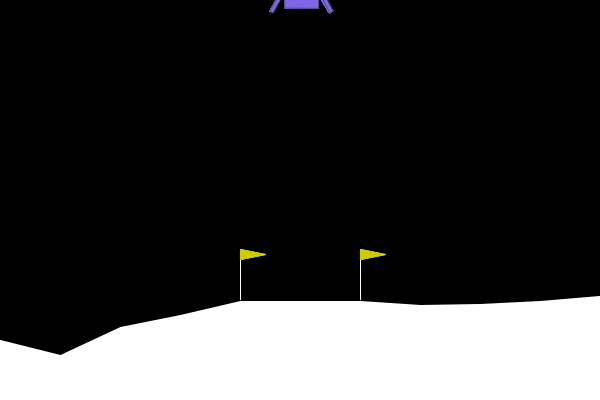

In [11]:
env = gym.make("LunarLander-v3", render_mode="rgb_array")

initial_state, _ = env.reset()
img = env.render()

PIL.Image.fromarray(img)

In [12]:
state_size = env.observation_space.shape
num_actions = env.action_space.n

print('State Shape:', state_size)
print('Number of actions:', num_actions)

State Shape: (8,)
Number of actions: 4


In [14]:
# Select an action
action = 0

# Run a single time step of the environment's dynamics with the given action.
next_state, reward, done, _, info = env.step(action)

with np.printoptions(formatter={'float': '{:.3f}'.format}):
    print("Initial State:", initial_state)
    print("Action:", action)
    print("Next State:", next_state)
    print("Reward Received:", reward)
    print("Episode Terminated:", done)
    print("Info:", info)

Initial State: [0.004 1.416 0.402 0.238 -0.005 -0.091 0.000 0.000]
Action: 0
Next State: [0.012 1.425 0.402 0.185 -0.014 -0.090 0.000 0.000]
Reward Received: 0.3088530135904648
Episode Terminated: False
Info: {}


In [16]:
# Create the Q-Network
q_network = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=state_size),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=num_actions, activation='linear'),
    ])

# Create the target Q^-Network
target_q_network = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=state_size),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=num_actions, activation='linear'),
    ])

optimizer = tf.keras.optimizers.Adam(learning_rate=ALPHA)

In [17]:
# Store experiences as named tuples
experience = namedtuple("Experience", field_names=["state", "action", "reward", "next_state", "done"])

In [18]:
def compute_loss(experiences, gamma, q_network, target_q_network):
    """
    Calculates the loss.

    Args:
      experiences: (tuple) tuple of ["state", "action", "reward", "next_state", "done"] namedtuples
      gamma: (float) The discount factor.
      q_network: (tf.keras.Sequential) Keras model for predicting the q_values
      target_q_network: (tf.keras.Sequential) Karas model for predicting the targets

    Returns:
      loss: (TensorFlow Tensor(shape=(0,), dtype=int32)) the Mean-Squared Error between
            the y targets and the Q(s,a) values.
    """

    # Unpack the mini-batch of experience tuples
    states, actions, rewards, next_states, done_vals = experiences

    # Compute max Q^(s,a)
    max_qsa = tf.reduce_max(target_q_network(next_states), axis=-1)

    # Set y = R if episode terminates, otherwise set y = R + γ max Q^(s,a).
    y_targets = rewards + (gamma * max_qsa * (1 - done_vals))

    # Get the q_values
    q_values = q_network(states)
    q_values = tf.gather_nd(q_values, tf.stack([tf.range(q_values.shape[0]),
                                                tf.cast(actions, tf.int32)], axis=1))

    # Compute the loss
    ### START CODE HERE ###
    loss = tf.keras.losses.MSE(y_targets, q_values)
    ### END CODE HERE ###

    return loss

In [19]:
@tf.function
def agent_learn(experiences, gamma):
    """
    Updates the weights of the Q networks.

    Args:
      experiences: (tuple) tuple of ["state", "action", "reward", "next_state", "done"] namedtuples
      gamma: (float) The discount factor.

    """

    # Calculate the loss
    with tf.GradientTape() as tape:
        loss = compute_loss(experiences, gamma, q_network, target_q_network)

    # Get the gradients of the loss with respect to the weights.
    gradients = tape.gradient(loss, q_network.trainable_variables)

    # Update the weights of the q_network.
    optimizer.apply_gradients(zip(gradients, q_network.trainable_variables))

    # update the weights of target q_network
    update_target_network(q_network, target_q_network)

In [62]:
start = time.time()

num_episodes = 2000
max_num_timesteps = 1000

total_point_history = []

num_p_av = 100    # number of total points to use for averaging
epsilon = 1.0     # initial ε value for ε-greedy policy

# Create a memory buffer D with capacity N
memory_buffer = deque(maxlen=MEMORY_SIZE)

# Set the target network weights equal to the Q-Network weights
target_q_network.set_weights(q_network.get_weights())

for i in range(num_episodes):

    # Reset the environment to the initial state and get the initial state
    state = env.reset()[0]
    total_points = 0

    for t in range(max_num_timesteps):

        # From the current state S choose an action A using an ε-greedy policy
        state_qn = np.expand_dims(state, axis=0)  # state needs to be the right shape for the q_network
        q_values = q_network(state_qn)
        action = get_action(q_values, epsilon)

        # Take action A and receive reward R and the next state S'
        next_state, reward, done, _1, _2 = env.step(action)

        # Store experience tuple (S,A,R,S') in the memory buffer.
        # We store the done variable as well for convenience.
        memory_buffer.append(experience(state, action, reward, next_state, done))

        # Only update the network every NUM_STEPS_FOR_UPDATE time steps.
        update = check_update_conditions(t, NUM_STEPS_FOR_UPDATE, memory_buffer)

        if update:
            # Sample random mini-batch of experience tuples (S,A,R,S') from D
            experiences = get_experiences(memory_buffer)

            # Set the y targets, perform a gradient descent step,
            # and update the network weights.
            agent_learn(experiences, GAMMA)

        state = next_state.copy()
        total_points += reward

        if done:
            break

    total_point_history.append(total_points)
    av_latest_points = np.mean(total_point_history[-num_p_av:])

    # Update the ε value
    epsilon = get_new_eps(epsilon)

    print(f"\rEpisode {i+1} | Total point average of the last {num_p_av} episodes: {av_latest_points:.2f}", end="")

    if (i+1) % num_p_av == 0:
        print(f"\rEpisode {i+1} | Total point average of the last {num_p_av} episodes: {av_latest_points:.2f}")

    # We will consider that the environment is solved if we get an
    # average of 200 points in the last 100 episodes.
    if av_latest_points >= 200.0:
        print(f"\n\nEnvironment solved in {i+1} episodes!")
        q_network.save('lunar_lander_model.h5')
        break

tot_time = time.time() - start

print(f"\nTotal Runtime: {tot_time:.2f} s ({(tot_time/60):.2f} min)")

Streaming output truncated to the last 5000 lines.
Next State: [-0.10830431  0.9483835  -0.13777311 -0.04513691 -0.25069132  0.04836863
  0.          0.        ]
[-0.10830431  0.9483835  -0.13777311 -0.04513691 -0.25069132  0.04836863
  0.          0.        ]
Next State: [-0.10933151  0.9477881  -0.10574837 -0.02594542 -0.24759635  0.06189921
  0.          0.        ]
[-0.10933151  0.9477881  -0.10574837 -0.02594542 -0.24759635  0.06189921
  0.          0.        ]
Next State: [-0.11027565  0.94655055 -0.09524574 -0.05486161 -0.24674898  0.01694717
  0.          0.        ]
[-0.11027565  0.94655055 -0.09524574 -0.05486161 -0.24674898  0.01694717
  0.          0.        ]
Next State: [-0.11102333  0.9454146  -0.07595455 -0.05028953 -0.24554977  0.02398453
  0.          0.        ]
[-0.11102333  0.9454146  -0.07595455 -0.05028953 -0.24554977  0.02398453
  0.          0.        ]
Next State: [-0.11186256  0.94371086 -0.08747517 -0.07513472 -0.24194539  0.07208751
  0.          0.        

KeyboardInterrupt: 

In [ ]:
# Plot the point history
plot_history(total_point_history)

In [ ]:
# Suppress warnings from imageio
import logging
logging.getLogger().setLevel(logging.ERROR)

In [ ]:
filename = "./videos/lunar_lander.mp4"

create_video(filename, env, q_network)
embed_mp4(filename)

In [4]:
#@title RL Simple Example

import numpy as np

# Simple 4x4 grid: 0=empty, -1=wall, +10=goal, -10=pit
# State: (row, col), Actions: 0=up, 1=right, 2=down, 3=left

class GridWorld:
    def __init__(self, size=4):
        self.size = size
        self.goal = (3, 3)
        self.pit = (1, 3)
        self.reset()

    def reset(self):
        self.pos = (0, 0)
        return self.pos

    def step(self, action):
        moves = [(-1,0),(0,1),(1,0),(0,-1)]
        dr, dc = moves[action]
        r, c = self.pos
        new_r = max(0, min(self.size-1, r + dr))
        new_c = max(0, min(self.size-1, c + dc))
        self.pos = (new_r, new_c)

        if self.pos == self.goal:
            return self.pos, +10.0, True
        elif self.pos == self.pit:
            return self.pos, -10.0, True
        else:
            return self.pos, -0.1, False

# Q-Learning
env = GridWorld()
Q = np.zeros((4, 4, 4))   # Q[row, col, action]
alpha, gamma, epsilon = 0.1, 0.9, 0.3

for episode in range(5000):
    s = env.reset()
    for _ in range(50):
        r, c = s
        # ε-greedy action selection
        if np.random.random() < epsilon:
            a = np.random.randint(4)
        else:
            a = np.argmax(Q[r, c])

        s_next, reward, done = env.step(a)
        r2, c2 = s_next

        # TD update
        td_target = reward + gamma * np.max(Q[r2, c2]) * (not done)
        Q[r, c, a] += alpha * (td_target - Q[r, c, a])

        s = s_next
        if done:
            break

# Evaluate learned policy
s = env.reset()
path = [s]
for _ in range(20):
    r, c = s
    a = np.argmax(Q[r, c])
    s, reward, done = env.step(a)
    path.append(s)
    if done:
        break

print("Optimal path:", path)
print("Reached goal:", path[-1] == (3, 3))

Optimal path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (3, 2), (3, 3)]
Reached goal: True
